## Gray Level Image (Grayscale)

A **digital gray level image** (often referred to as a grayscale image) is a type of digital image where each pixel represents a single intensity value. This value corresponds strictly to the amount of light or brightness at that specific point, entirely devoid of color information. The visual output consists exclusively of shades of gray, ranging from absolute black at the weakest intensity to pure white at the strongest intensity.

*(Insert Original Lena Image Comparison Here)*

### How is a Color Image Converted to Grayscale?
To convert a standard RGB color image into a gray level image, the system must reduce three color channels down to one. Because the human eye is more sensitive to green light than red or blue, a weighted sum formula is typically applied to calculate the luminance ($Y$) for each pixel:

$$Y = 0.299R + 0.587G + 0.114B$$

### Key Characteristics of Digital Gray Level Images
1. **Pixel Intensity**: Each pixel in a gray level image has an intensity value that indicates its brightness. This value is typically represented as an integer within a specific range, such as 0 to 255 for 8-bit images, where 0 represents black and 255 represents white.

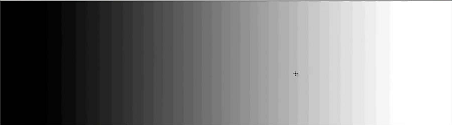

2. **Bit Depth:** The number of bits assigned to represent each pixel dictates the total number of available gray levels (shades of gray).
   * **8-bit:** $2^8 = 256$ gray levels (Values from $0$ to $255$). This is the standard for most basic image processing tasks.
   * **16-bit:** $2^{16} = 65,536$ gray levels (Values from $0$ to $65,535$). Frequently used in high-precision fields like medical diagnostics and astrophotography.

3. **Quantization:** The essential step-by-step process of mapping a continuous range of light intensities (analog signals from the real world) into a finite, discrete set of integer levels. This allows the continuous tone to be digitally stored and processed.

4. **Applications and Efficiency:** Gray level images are widely used in fields such as medical imaging (e.g., X-rays, mammograms), remote sensing, and document analysis. In Computer Vision, converting images to grayscale is often a crucial first step; it reduces computational complexity by focusing on structural details (like edges and shapes) without the overhead of processing three separate color channels.

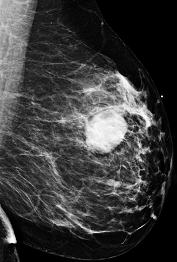

## Comparison with Color Images

When designing computer vision pipelines, choosing between grayscale and color depends heavily on the trade-off between information retention and computational efficiency.

| Feature | Gray Level Image (Grayscale) | Color Image (RGB) |
| :--- | :--- | :--- |
| **Pixel Representation** | Single intensity value | Multiple values (e.g., Red, Green, Blue channels) |
| **Matrix Shape** | $H \times W$ (2D Array) | $H \times W \times 3$ (3D Array) |
| **Storage Requirement** | Lower (e.g., 8 bits per pixel) | Higher (e.g., 24 bits per pixel) |
| **Computational Speed** | Fast (Ideal for real-time preprocessing) | Slower (Requires processing 3x the data) |
| **Primary Use Cases** | Structural analysis, medical imaging, document scanning | Photography, human-computer interaction, graphic design |

## Examples of Practical Use
Grayscale images are foundational in areas where structure, contrast, and shape are more important than color details.

* **Medical Imaging:** High bit-depth gray level images (e.g., 12-bit or 16-bit) are used to capture extremely fine differences in tissue density in X-ray, Ultrasound, or MRI scans, allowing for precise medical diagnostics.

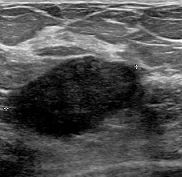

* **Document Scanning and Analysis:** Converting colored documents to grayscale is a necessary preliminary step for digitizing text. It removes colored background noise, making it significantly easier to apply thresholding techniques and extract text using OCR (Optical Character Recognition) systems.

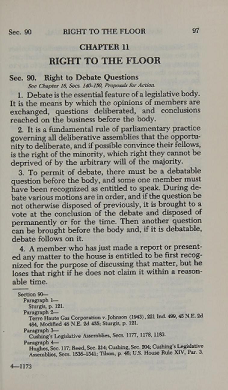

* **Remote Sensing & Object Detection:** Satellite images often use gray level representation to highlight structural variations in terrain and vegetation. Furthermore, in modern object detection workflows (such as identifying buildings or vehicles from aerial imagery using frameworks like YOLO), grayscale conversion is typically combined with image enhancement techniques to improve model accuracy.  Based on the provided satellite imagery, a standard enhancement pipeline consists of the following steps:
   - **Original Image:** The raw satellite capture, which may suffer from low contrast or sensor noise.
   - **Gray Level Conversion:** Discarding unnecessary color data to focus purely on topographical structures and reducing processing overhead.
   - **Gaussian Filtering:** Applying a smoothing filter (blur) to reduce high-frequency noise and artificial artifacts, ensuring the core structures remain intact.
   - **Histogram Equalization:** Redistributing the most frequent intensity values to enhance the global contrast. This makes the hidden features and edges stand out clearly for both human analysis and machine learning algorithms.

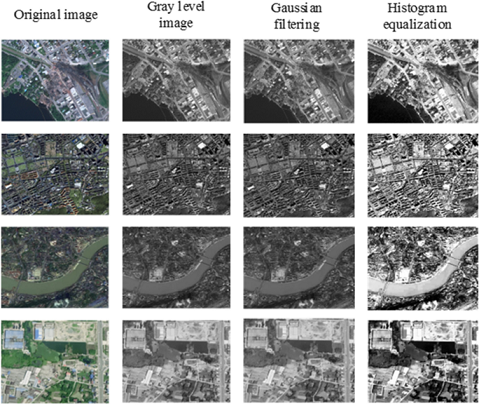

In summary, a digital gray level image is a fundamental type of image in digital imaging that captures and represents the intensity of light at each pixel, making it a versatile tool in various scientific and practical applications.



In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

### <span style='color:lightblue;'>1. Importing color images and display results using functions from cv2</span>  

In [3]:
fp = "./images/lena_color_256.tif"
img = cv2.imread(fp)

In [4]:
print(type(img))
print(img.shape)

<class 'numpy.ndarray'>
(256, 256, 3)


In [5]:
cv2.imshow("color image",img)
cv2.waitKey(0)
cv2.destroyAllWindows()

### <span style='color:lightblue;'>2. Importing color images and display results using functions from matplotlib.pyplot</span>  

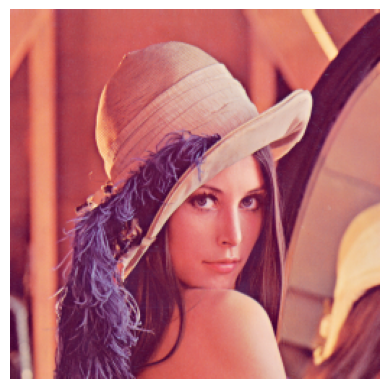

In [6]:
plt.axis("off")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
#plt.show()
plt.savefig('./outs/output.png')


### <span style='color:lightblue;'>3.Saving image files</span>   
From the example, open the image file in TIFF format but save it as png.

In [ ]:
cv2.imwrite('./outs/lena_color_256.jpg',img.astype(np.uint8))

In [ ]:
del(img)
del(fp)

### <span style='color:lightblue;'>4. Converting Color  to Grayscale Image</span>   


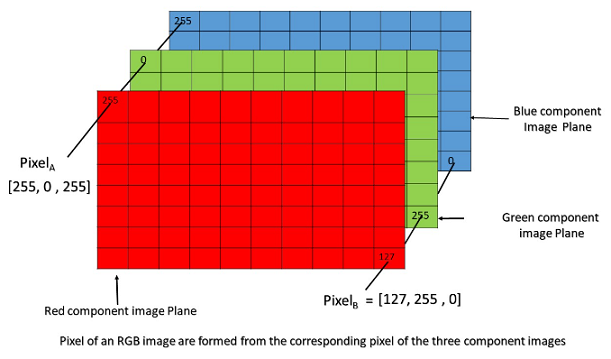

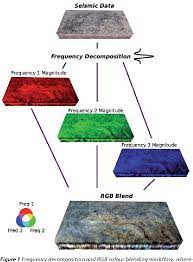

#### <span style='color:yellow;'>Method I</span>   

<class 'numpy.ndarray'>
(139, 162)


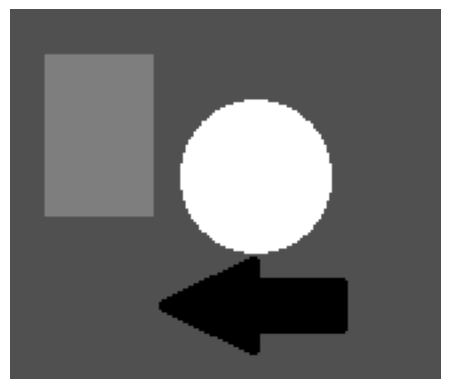

In [7]:
fp = "./images/test_color.png"
img = cv2.imread( "./images/test_color.png", 0)
print(type(img))
print(img.shape)
plt.axis("off")
plt.imshow(img, cmap='gray')
plt.show()

In [ ]:
del(img)
del(fp)

#### <span style='color:yellow;'>Method II</span>   

In [ ]:
fp = "./images/test_color.png"
img = cv2.imread(fp)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.axis("off")
plt.imshow(gray, cmap='gray')
plt.show()

In [ ]:
del(img)
del(fp)

#### <span style='color:yellow;'>Method III : Linear Equation</span>   
**<span style='color:orange;'>Coordinate Pixels Visiting</span>**

In [8]:
fp = "./images/mandril_color.tif"
img = cv2.imread(fp)


In [9]:
r = img[:,:,2].astype(np.float32)
g = img[:,:,1].astype(np.float32)
b = img[:,:,0].astype(np.float32)
# b,g,r = cv2.split(img)
m,n = r.shape

In [10]:
#gray = np.zeros((m,n), dtype='float')
gray = np.zeros_like(r, dtype='float')

for i in range(m):
    for j in range(n):
        gray[i,j] = 0.2989*r[i,j] + 0.5870*g[i,j] + 0.1140*b[i,j]

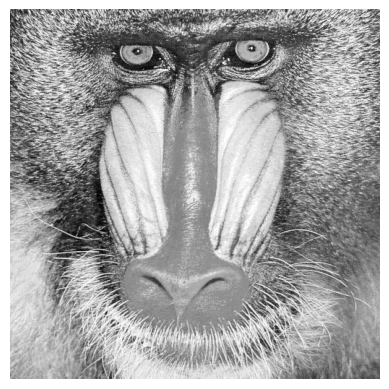

True

In [11]:
plt.axis("off")
plt.imshow(gray, cmap='gray')
plt.show()
cv2.imwrite('./outs/output.png',gray.astype(np.uint8))

**<span style='color:orange;'> Matrix Operation</span>**

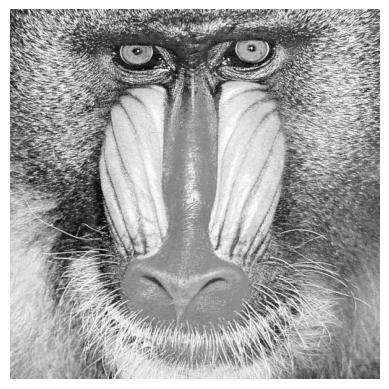

True

In [12]:
fp = "./images/mandril_color.tif"
img = cv2.imread(fp)
b = 0.1140*img[:,:,0].astype(np.float16)
g = 0.5870*img[:,:,1].astype(np.float16)
r = 0.2989*img[:,:,2].astype(np.float16)
gray = b + g + r
gray = gray.astype(np.uint8) 
plt.axis("off")
plt.imshow(gray, cmap='gray')
plt.show()
cv2.imwrite('./outs/mandril_gray.png',gray)

In [ ]:
del(img)
del(fp)

### <span style='color:lightblue;'>5. Using cv2.hconcat, cv2.vconcat to concatenate color space arrays in horizon and vertical directions.</span>   


In [ ]:
#fp = "./images/mandril_color.tif"
fp = "./images/test_color.png"
img = cv2.imread(fp)

b = img[:,:,0]
g = img[:,:,1]
r = img[:,:,2]
gray3space = cv2.hconcat([r, g, b])
plt.axis("off")
plt.imshow(gray3space, cmap='gray')
plt.show()

In [ ]:
del(img)
del(fp)

## What is a Digital Image Histogram?

A digital image histogram is a graphical representation of the tonal distribution in a digital image. It acts as a fundamental statistical tool in image processing.

### Key Characteristics

1. **Definition:** An image histogram plots the number of pixels for each specific tonal value (gray level) present in an image.
2. **Visual Representation:** * **Horizontal Axis ($x$-axis):** Represents the tonal variations or intensity levels from dark to light (e.g., $0$ to $255$ for a standard 8-bit image).
   * **Vertical Axis ($y$-axis):** Shows the frequency, or the total number of pixels, at each specific tonal level.
3. **Tonal Range:**
   * **Left side:** Represents shadows and dark areas (intensities near $0$).
   * **Middle:** Represents midtones.
   * **Right side:** Represents highlights and bright areas (intensities near $255$).
4. **Information Provided:**
   * Shows the global distribution of pixel intensities across the entire image.
   * Helps objectively assess exposure, contrast, and dynamic range, which is a critical analytical step before feeding image data into more complex computer vision models.

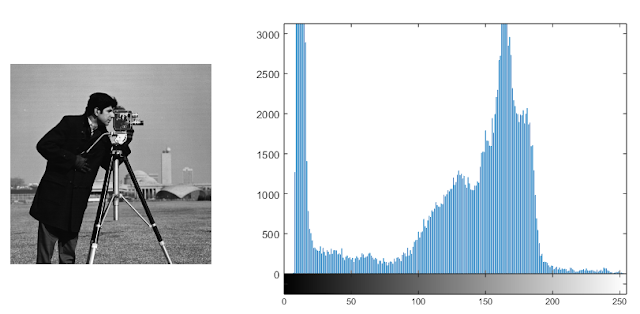

### Step-by-Step: How a Histogram is Computed

To understand the mechanics behind the graph, here is how a computer programmatically generates a histogram from an $M \times N$ image matrix:

1. **Initialization:** Create a 1-Dimensional array (the histogram array) with a size equal to the number of possible intensity levels (e.g., 256 bins for an 8-bit image). Initialize all bin values to $0$.
2. **Iteration:** Traverse every single pixel coordinate $(i, j)$ within the spatial domain of the image matrix.
3. **Accumulation:** For each pixel, read its intensity value $f(i,j) = k$. Increment the value of the $k$-th bin in the histogram array by $1$.

Mathematically, the unnormalized histogram is defined as:
$$h(r_k) = n_k$$
Where $r_k$ is the $k$-th gray level and $n_k$ is the total number of pixels in the image having that exact gray level.

4. **Normalization (Optional but Common):** To compare images of different sizes, the histogram is often normalized by dividing each bin by the total number of pixels ($M \times N$). This converts the histogram into a Probability Density Function (PDF).
$$p(r_k) = \frac{n_k}{M \times N}$$

#### <span style='color:yellow;'>Method I: Create Histogram array using cv2.calcHist </span>      

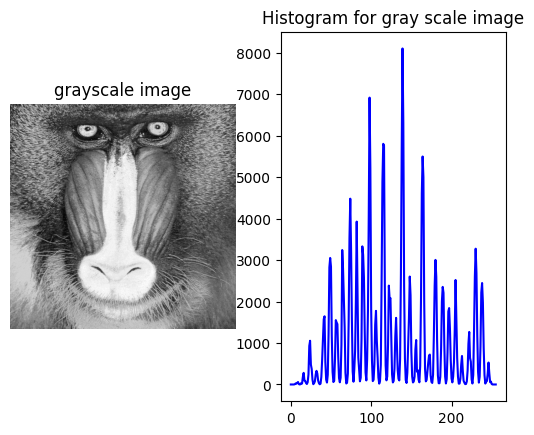

In [15]:
fp = "./images/mandril_color.tif"
img = cv2.imread(fp)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
i = 2
hist= cv2.calcHist([img], [i], None, [256], [0,256])

fig = plt.figure()
fig.add_subplot(1, 2, 1)
plt.imshow(img[:,:,i], cmap = 'gray')
plt.axis('off')
plt.title("grayscale image")
  
fig.add_subplot(1, 2, 2)
plt.plot(hist, color='b')
plt.title('Histogram for gray scale image')
plt.show()


In [ ]:
print(hist)

In [17]:
del(img)
del(fp)
del(hist)
del(gray)

#### <span style='color:yellow;'>Method II: Show Histogram using plt.hist</span>        

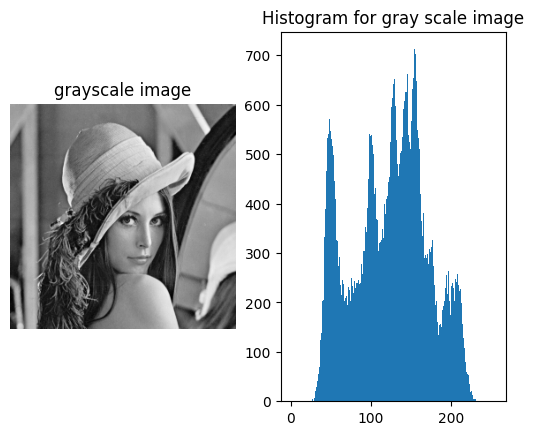

In [21]:
fp = "./images/lena_color_256.tif"
img = cv2.imread(fp)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
fig = plt.figure()
fig.add_subplot(1, 2, 1)
plt.imshow(gray, cmap = 'gray')
plt.axis('off')
plt.title("grayscale image")
  
fig.add_subplot(1, 2, 2)
plt.hist(gray.ravel(),256,[0,256])
plt.title('Histogram for gray scale image')
plt.show()


In [22]:
del(img)
del(fp)
del(gray)

#### <span style='color:yellow;'>Method III: Show Histogram using frequency array</span>        

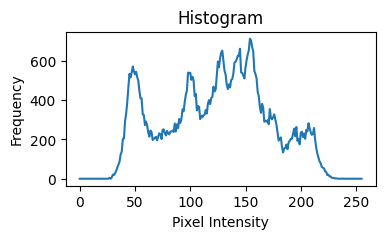

In [23]:
fp = "./images/lena_color_256.tif"
img = cv2.imread(fp)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hist_img = np.zeros(256)
row, col = gray.shape
for i in range(row):
    for j in range(col):
        intens = gray[i, j]
        hist_img[intens] += 1

plt.figure(figsize=(4,2))
plt.plot(hist_img)
plt.title('Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()


### <span style='color:lightgreen;'>Histogram of Color Image </span> 

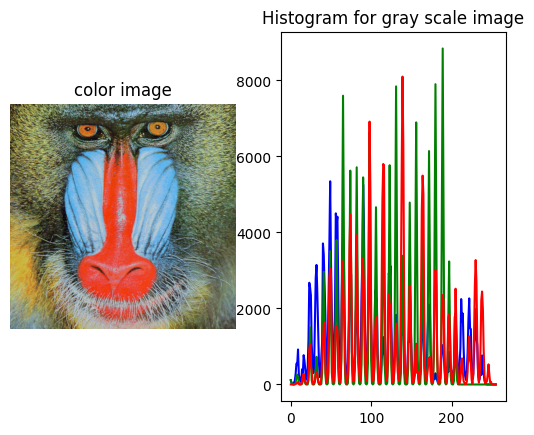

In [24]:
fp = "./images/mandril_color.tif"
img = cv2.imread(fp)

fig = plt.figure()
fig.add_subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("color image")
r, c, n = img.shape 
color_fig = ['b', 'g', 'r']
fig.add_subplot(1, 2, 2)
for i in range(n):
    hist= cv2.calcHist([img], [i], None, [256], [0,256])
    plt.plot(hist, color= color_fig[i])
plt.title('Histogram for gray scale image')
plt.show()

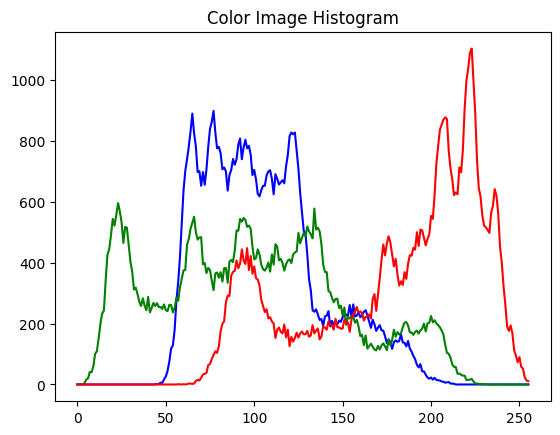

In [25]:
fp = "./images/lena_color_256.tif"
img = cv2.imread(fp)
colors = ('b','g','r')
for i,color in enumerate(colors):
    hist = cv2.calcHist([img],[i],None,[256],[0,256])
    plt.plot(hist,color = color)
plt.title('Color Image Histogram')
plt.show()